# Mercedes Global Sales 2020–2025

### Datenquelle, Ziel der Analyse, Forschungsfragen und Zielvariable

Der Datensatz stammt von Kaggle:

Dhrubang Talukdar (2025)
Mercedes Global Car Sales (2020–2025)

https://www.kaggle.com/datasets/dhrubangtalukdar/mercedes-global-car-sales-2020-2025

---

Ziel der Analyse:

Untersuchung der Einflussfaktoren auf den Basispreis (USD) von Mercedes-Benz Fahrzeugen.

---

Forschungsfragen:

1. Welche Merkmale beeinflussen den Basispreis signifikant?
2. Wie gut lässt sich der Basispreis anhand technischer und struktureller Merkmale vorhersagen?

---

Zielvariable:

Base Price (USD)

## Setup
### Imports, Pfade und Helper

In [12]:
from pathlib import Path
from pathlib import PurePath
import sys
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from ydata_profiling import ProfileReport

# Pfade
BASE_DIR = Path.cwd()

INPUT_RAW = BASE_DIR / "input" / "raw"
INPUT_PROCESSED = BASE_DIR / "input" / "processed"

OUTPUT_DIR = BASE_DIR / "output"
OUTPUT_FIGURES = OUTPUT_DIR / "figures"

FIG_EDA = OUTPUT_FIGURES / "eda"
FIG_MODELING = OUTPUT_FIGURES / "modeling"
DOCS_DIR = BASE_DIR / "docs"

# Ordner anlegen
for p in [INPUT_PROCESSED, OUTPUT_FIGURES, FIG_EDA, FIG_MODELING, DOCS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

DATA_FILE = INPUT_RAW / "mercedes_benz_sales_2020_2025.csv"


# Helper
def _slugify(text: str) -> str:
    text = (text or "").strip()
    text = re.sub(r"[^\w\s-]", "", text)
    return text if text else "Plot"

def _next_plot_number(fig_dir: Path) -> int:
    pattern = re.compile(r"^(\d{2,})_.*\.png$", re.IGNORECASE)
    nums = []
    for p in fig_dir.glob("*.png"):
        m = pattern.match(p.name)
        if m:
            nums.append(int(m.group(1)))
    return (max(nums) + 1) if nums else 1

plot_counter_eda = _next_plot_number(FIG_EDA)

def save_current_plot_eda(dpi: int = 300):
    
    global plot_counter_eda

    fig = plt.gcf()
    if fig is None or len(fig.axes) == 0:
        print("Kein Plot zum Speichern")
        return

    title = plt.gca().get_title() or "plot"
    filename = f"{plot_counter_eda:02d} {_slugify(title)}.png"
    filepath = FIG_EDA / filename

    if filepath.exists():
        project_name = BASE_DIR.name
        relative_path = filepath.relative_to(BASE_DIR)
        full_display_path = PurePath(project_name) / relative_path
        print(f"Übersprungen: {full_display_path}")
    else:
        fig.tight_layout()
        fig.savefig(filepath, dpi=dpi, bbox_inches="tight")

        project_name = BASE_DIR.name
        relative_path = filepath.relative_to(BASE_DIR)
        full_display_path = PurePath(project_name) / relative_path
        print(f"Gespeichert: {full_display_path}")

    plot_counter_eda += 1



### Profiling Report

In [13]:
df = pd.read_csv(DATA_FILE)

report_path = DOCS_DIR / "Mercedes_Sales_Profiling.html"

if report_path.exists():
    print("Profiling Report existiert bereits unter: docs")
    print("Erstellung übersprungen")
else:
    print("Erstelle Profiling Report...")

    profile = ProfileReport(
        df,
        title="Mercedes-Benz Global Sales — Profiling Report",
        explorative=True,
        minimal=True,
        progress_bar=True
    )

    profile.to_file(report_path)

    print("Profiling Report gespeichert")
  

Profiling Report existiert bereits unter: docs
Erstellung übersprungen


## Datenqualität

In [14]:
# Daten laden
df = pd.read_csv(DATA_FILE)
print("Form:", df.shape)

# Struktur und Datentyp
df.info()
df.head()

Form: (12132666, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12132666 entries, 0 to 12132665
Data columns (total 9 columns):
 #   Column            Dtype 
---  ------            ----- 
 0   Model             object
 1   Year              int64 
 2   Region            object
 3   Color             object
 4   Fuel Type         object
 5   Base Price (USD)  int64 
 6   Horsepower        int64 
 7   Sales Volume      int64 
 8   Turbo             object
dtypes: int64(4), object(5)
memory usage: 833.1+ MB


,Model,Year,Region,Color,Fuel Type,Base Price (USD),Horsepower,Sales Volume,Turbo
0,A-Class,2020,Global,Yellow,Diesel,41265,252,1,Yes
1,A-Class,2020,Global,Black,Petrol,51023,249,1,No
2,A-Class,2020,Global,Grey,Petrol,72819,341,1,Yes
3,A-Class,2020,Global,Black,Petrol,62480,385,1,Yes
4,A-Class,2020,Global,White,Petrol,35189,337,1,Yes


- 12.132.666 Beobachtungen und 9 Variablen  
- 4 numerische und 5 kategoriale Variablen  
- Struktur konsistent und plausibel  
- Keine offensichtlichen Format- oder Typfehler  
- Hoher Speicherbedarf (~833 MB) -> relevant für Performance  

### Fehlende Werte prüfen

In [15]:
df.isna().sum()

Model               0
Year                0
Region              0
Color               0
Fuel Type           0
Base Price (USD)    0
Horsepower          0
Sales Volume        0
Turbo               0
dtype: int64

- Keine fehlenden Werte in allen 9 Variablen
- Keine Imputation erforderlich
- Keine Reduktion der Stichprobengröße notwendig
- Datensatz vollständig für weitere Analyse nutzbar

### Duplikate prüfen

In [16]:
# Übersicht
n_duplicates = df.duplicated().sum()
n_total = len(df)
percentage = (n_duplicates / n_total) * 100

dup_summary = pd.DataFrame({
    "Kennzahl": ["Gesamtbeobachtungen", "Duplikate", "Anteil (%)"],
    "Wert": [
        f"{n_total:,.0f}".replace(",", "."),
        f"{n_duplicates:,.0f}".replace(",", "."),
        f"{percentage:.4f}"
    ]
})

dup_summary


,Kennzahl,Wert
0,Gesamtbeobachtungen,12.132.666
1,Duplikate,3.153
2,Anteil (%),0.0260


- 3.153 doppelte Beobachtungen identifiziert  
- Anteil sehr gering (~0,026 %)  
- Für die spätere Modellierung bereinigen  

In [17]:
# Duplikate entfernen
n_before = len(df)

df = df.drop_duplicates()

n_after = len(df)
removed = n_before - n_after

print(f"Entfernte Duplikate: {removed:,}".replace(",", "."))
print(f"Neue Anzahl Beobachtungen: {n_after:,}".replace(",", "."))

Entfernte Duplikate: 3.153
Neue Anzahl Beobachtungen: 12.129.513


- 3.153 Duplikate entfernt  
- Datensatz strukturell bereinigt  
- Keine künstliche Mehrfachgewichtung einzelner Konfigurationen  
- Grundlage für unverzerrte Modellschätzung geschaffen  

## Explorative Datenanalyse (EDA)

### Univariaten Analyse - Base Price (USD)

In [18]:
# Übersicht
df["Base Price (USD)"].describe()

count    1.212951e+07
mean     1.042226e+05
std      6.783929e+04
min      3.500000e+04
25%      6.346400e+04
50%      8.357400e+04
75%      1.199280e+05
max      4.112460e+05
Name: Base Price (USD), dtype: float64

Übersprungen: Mercedes_Global_Sales\output\figures\eda\01 Verteilung mit Quantilbereichen.png


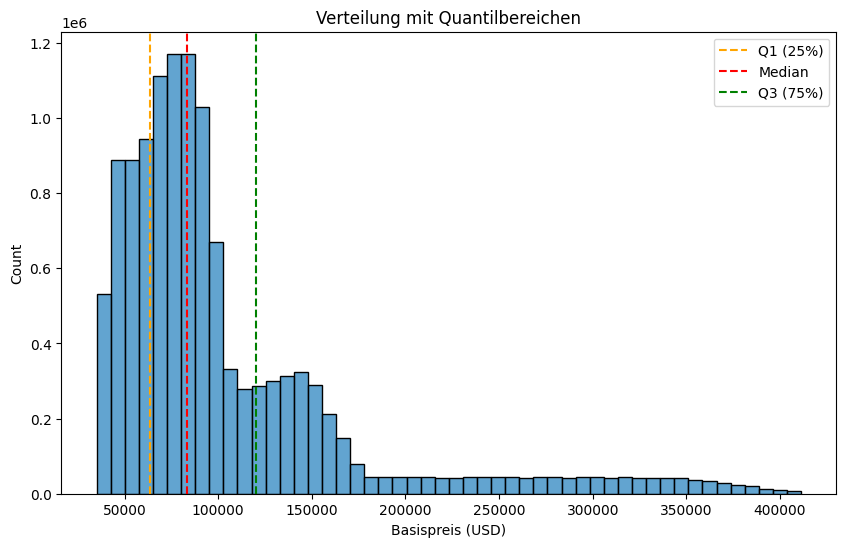

0.25     63464.0
0.50     83574.0
0.75    119928.0
Name: Base Price (USD), dtype: float64

In [19]:
# Quantilbereich 
q1 = df["Base Price (USD)"].quantile(0.25)
median = df["Base Price (USD)"].quantile(0.5)
q3 = df["Base Price (USD)"].quantile(0.75)

plt.figure(figsize=(10,6))

sns.histplot(df["Base Price (USD)"], bins=50, color="#2E86C1")

plt.axvline(q1, color="orange", linestyle="--", label="Q1 (25%)")
plt.axvline(median, color="red", linestyle="--", label="Median")
plt.axvline(q3, color="green", linestyle="--", label="Q3 (75%)")

plt.legend()
plt.title("Verteilung mit Quantilbereichen")
plt.xlabel("Basispreis (USD)")

save_current_plot_eda()

plt.show()

df["Base Price (USD)"].quantile([0.25, 0.5, 0.75])


- 25 %-Quantil bei ca. 63.464 USD  
- Median bei ca. 83.574 USD  
- 75 %-Quantil bei ca. 119.928 USD  
- 50 % der Fahrzeuge liegen im Interquartilsbereich von ca. 63.000–120.000 USD  
- Langer rechter Verteilungsschwanz bis über 400.000 USD  
- Hochpreisige Modelle erhöhen den arithmetischen Mittelwert  

### Univariate Analyse – numerische Variablen

In [20]:
numeric_cols = df.select_dtypes(include="int64").columns

df[numeric_cols].describe()

,Year,Base Price (USD),Horsepower,Sales Volume
count,1.212951e+07,1.212951e+07,1.212951e+07,12129513.0
mean,2.022548e+03,1.042226e+05,3.674664e+02,1.0
std,1.658897e+00,6.783929e+04,1.195476e+02,0.0
min,2.020000e+03,3.500000e+04,1.500000e+02,1.0
25%,2.021000e+03,6.346400e+04,2.750000e+02,1.0
50%,2.023000e+03,8.357400e+04,3.580000e+02,1.0
75%,2.024000e+03,1.199280e+05,4.440000e+02,1.0
max,2.025000e+03,4.112460e+05,8.310000e+02,1.0


Übersprungen: Mercedes_Global_Sales\output\figures\eda\02 Base Price vs Horsepower PS.png


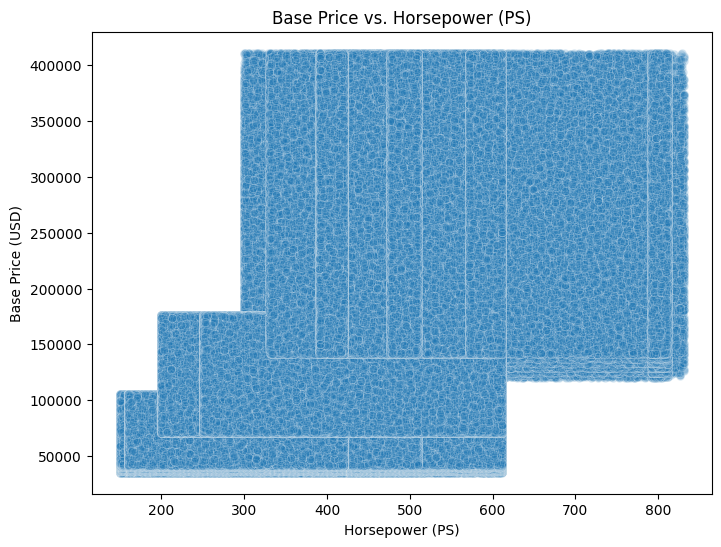

In [21]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["Horsepower"],
    y=df["Base Price (USD)"],
    alpha=0.2
)

plt.title("Base Price vs. Horsepower (PS)")
plt.xlabel("Horsepower (PS)")
plt.ylabel("Base Price (USD)")

save_current_plot_eda()

plt.show()

- mit über 12 Mio. Beobachtungen unübersichtlich
- keine erkennbare Struktur
- Overplotting

Übersprungen: Mercedes_Global_Sales\output\figures\eda\03 Durchschnittspreis je Horsepower PS.png


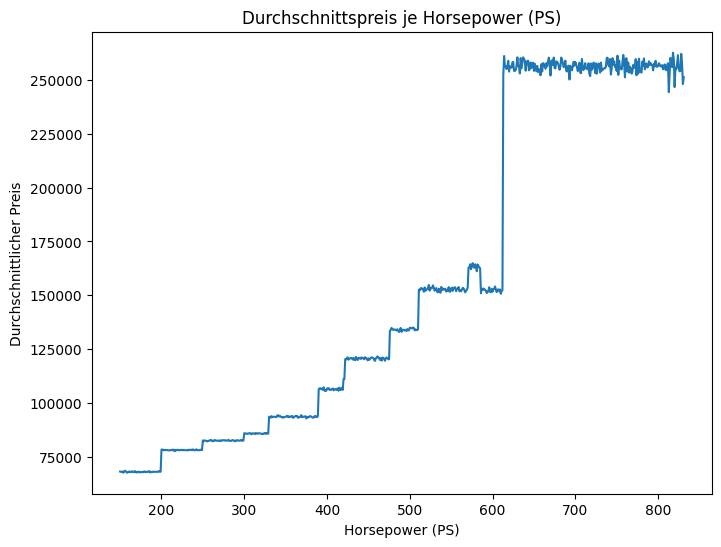

In [22]:
grouped = df.groupby("Horsepower")["Base Price (USD)"].mean()

plt.figure(figsize=(8,6))
plt.plot(grouped.index, grouped.values)
plt.title("Durchschnittspreis je Horsepower (PS)")
plt.xlabel("Horsepower (PS)")
plt.ylabel("Durchschnittlicher Preis")

save_current_plot_eda()

plt.show()

- Deutlicher positiver Zusammenhang zwischen PS und Preis
- Durchschnittspreis steigt stufenartig mit zunehmender Leistung
- Preisbildung erfolgt offenbar segmentbasiert (Modellklassen)
- Ab ca. 600 PS klarer Übergang ins Hochpreissegment
- Zusammenhang nicht strikt linear, sondern strukturell diskret

### Univariate Analyse – Horsepower

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Horsepower"],
    bins=40,
    kde=True
)

plt.title("Verteilung Horsepower (PS)")
plt.xlabel("Horsepower (PS)")
plt.ylabel("Häufigkeit")

save_current_plot_eda()

plt.show()

: 

: 

- Breite Streuung von ca. 150 bis über 800 PS
- Mehrheit der Fahrzeuge im mittleren Leistungssegment
- Leicht rechtsschiefe Verteilung
- Gute Varianz -> potenziell starker Preistreiber

### Bivariate Analyse

#### Base Price vs. Model

Übersprungen: Mercedes_Global_Sales\output\figures\eda\05 Base Price nach Modell Top 10.png


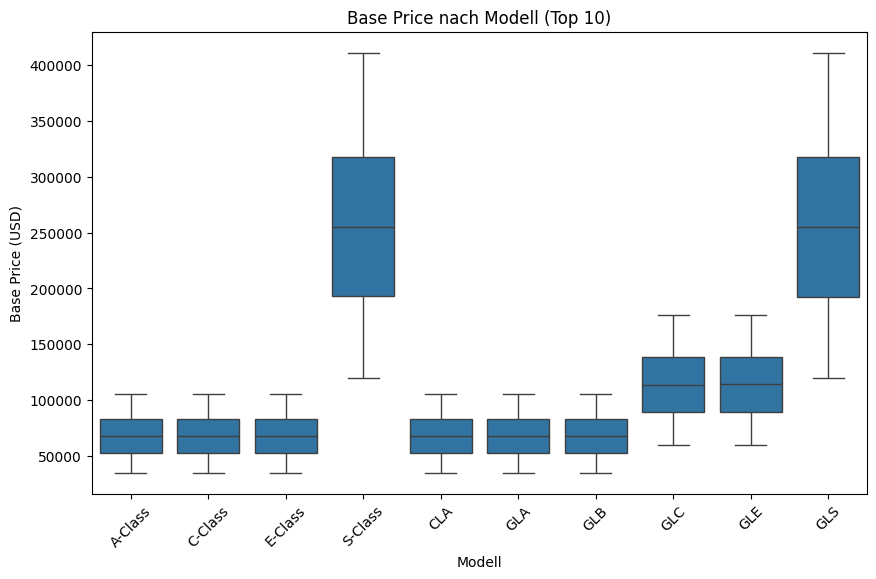

In [ ]:
top_models = df["Model"].value_counts().head(10).index

plt.figure(figsize=(10,6))

sns.boxplot(
    x="Model",
    y="Base Price (USD)",
    data=df[df["Model"].isin(top_models)]
)

plt.xticks(rotation=45)
plt.title("Base Price nach Modell (Top 10)")
plt.xlabel("Modell")
plt.ylabel("Base Price (USD)")

save_current_plot_eda()

plt.show()

- Deutliche Preisunterschiede zwischen Modellklassen
- S-Klasse / GLS im oberen Preissegment
- GLC und GLE im gehobenen SUV-Segment
- A-, C-, E- und kompakte Modelle im Kernpreissegment
- Modellklasse wirkt als struktureller Preistreiber

#### Base Price vs. Fuel Type

Übersprungen: Mercedes_Global_Sales\output\figures\eda\06 Preis je Fuel Type Median.png


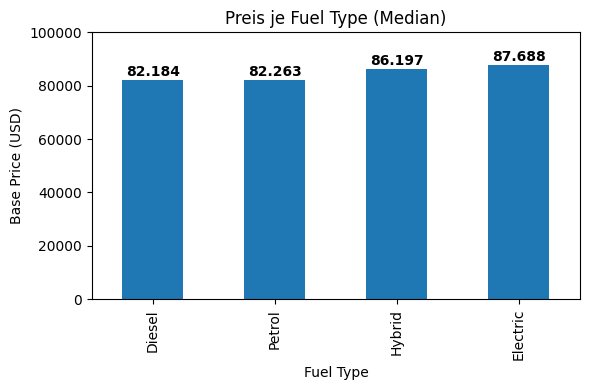

In [ ]:
median_fuel = df.groupby("Fuel Type")["Base Price (USD)"].median().sort_values()

plt.figure(figsize=(6,4))
ax = median_fuel.plot(kind="bar")

plt.title("Preis je Fuel Type (Median)")
plt.ylabel("Base Price (USD)")
plt.xlabel("Fuel Type")

plt.ylim(0, 100000)   # <-- Achse bis 100.000 USD

# Werte über Balken
for i, value in enumerate(median_fuel):
    ax.text(
        i,
        value + 1500,
        f"{value:,.0f}".replace(",", "."),
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()

save_current_plot_eda()

plt.show()

- Diesel und Petrol (Benzin) nahezu identisches Preisniveau  
- Hybrid und Electric leicht höherer Medianpreis  
- Differenz zwischen niedrigstem und höchstem Median ca. 5.500 USD  
- Einfluss des Fuel Type moderat und deutlich geringer als der Modelleffekt  
- Fuel Type wirkt als sekundärer Preistreiber  

## Export

In [ ]:
# Processed Dataset Export
PROCESSED_DIR = BASE_DIR / "input" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

processed_file = PROCESSED_DIR / "mercedes_sales_processed.csv"

if processed_file.exists():
    print(f"Übersprungen – Datei existiert bereits: {processed_file.name}")
else:
    df_processed = df.drop_duplicates().copy()
    
    if "Sales Volume" in df_processed.columns and df_processed["Sales Volume"].nunique() == 1:
        df_processed = df_processed.drop(columns=["Sales Volume"])
        print("Info: 'Sales Volume' entfernt (keine Varianz).")
    
    df_processed.to_csv(processed_file, index=False, encoding="utf-8")
    print(f"Gespeichert: {processed_file.relative_to(BASE_DIR)}")
    print(f"Form processed: {df_processed.shape}")

Übersprungen – Datei existiert bereits: mercedes_sales_processed.csv


- Duplikate entfernt
- Spalten ohne Varianz entfernt
- Keine Transformation oder Skalierung durchgeführt
- Struktur für Modellierung vorbereitet